# HPA201 MORBO vs Vanilla BO: Mean Hypervolume Over Repeated Runs

In [1]:
# Import necessary libraries
import warnings, os, torch, copy, random, time

os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from botorch.utils.multi_objective.box_decompositions.dominated import DominatedPartitioning

from optimpv import FitParam
from optimpv.models.HPA import HPAAgent, HPAModel
from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
from optimpv.optimizers.axBOtorch.axUtils import get_VMLC_default_model_kwargs_list

plt.style.use('default')

## Benchmark Setup

This notebook mirrors the repeated-run HPA benchmark notebooks, but uses a multi-objective HPA problem and compares `MORBO` against vanilla multi-objective BO (`BOTORCH_MODULAR`). The comparison signal is cumulative observed hypervolume.

In [ ]:
# Main notebook setup
# This notebook is configured for a multi-objective HPA problem.
# Change problem_name, n_div, and level to test a different unconstrained MOO HPA problem.
problem_name = 'HPA201'  # e.g. HPA201, HPA202, HPA203, HPA204, HPA205
n_div = 4
level = 0
normalized = True

total_evaluations = 100 #! * batch_size
n_init = 20
batch_size = 2

reference_point = [300.0, 10.0] # reference point for morbo

n_repeats = 1
seed_base = 1000

reference_sample_size = 128
reference_seed = 1234

variations = [
    {'label': 'Vanilla BO', 'method': 'vanilla_bo'},
    {'label': 'MORBO', 'method': 'morbo', 'n_trust_regions': 4},
]

print(f'Problem: {problem_name}-{level}')
print(f'Total evaluations per variation: {total_evaluations * batch_size}')
print(f'Repeats per variation: {n_repeats}')
print(f'Seed base: {seed_base}')
print('Variations:')
for variation in variations:
    print('  -', variation['label'])

Problem: HPA201-0
Total evaluations per variation: 200
Repeats per variation: 1
Seed base: 1000
Variations:
  - Vanilla BO
  - MORBO


In [3]:
# Build the HPA benchmark model and define the optimization parameters
hpa_model = HPAModel(
    problem_name=problem_name,
    n_div=n_div,
    level=level,
    normalized=normalized,
)

params = []
for i in range(hpa_model.nx):
    params.append(
        FitParam(
            name=f'x{i}',
            value=0.5,
            bounds=[0.0, 1.0],
            value_type='float',
            type='range',
            display_name=f'x{i}',
            axis_type='linear',
        )
    )

print(f'Dimension: {hpa_model.nx}D')
print(f'Number of objectives: {hpa_model.nf}')
print(f'Number of explicit constraints: {hpa_model.ng}')
print('Midpoint objective:', hpa_model.evaluate(np.full(hpa_model.nx, 0.5))[0])

Dimension: 18D
Number of objectives: 2
Number of explicit constraints: 0
Midpoint objective: [264.49237611  -8.19955094]


In [4]:
# Define the multi-objective Agent
hpa_agent = HPAAgent(
    params=params,
    problem_name=problem_name,
    n_div=n_div,
    level=level,
    normalized=normalized,
    metric=['f1', 'f2'],
    loss='linear',
    minimize=[True, True],
    name='hpa_moo',
)

print('Agent metric names:', hpa_agent.all_agent_metrics)

Agent metric names: ['hpa_moo_HPA201_f1_linear', 'hpa_moo_HPA201_f2_linear']


In [ ]:
# Put the optimizer building and hypervolume extraction into functions.

def build_optimizer(variation, seed=0):
    params_local = copy.deepcopy(params)
    agent_local = HPAAgent(
        params=params_local,
        problem_name=problem_name,
        n_div=n_div,
        level=level,
        normalized=normalized,
        metric=['f1', 'f2'],
        loss='linear',
        minimize=[True, True],
        name='hpa_moo',
    )

    if variation['method'] == 'vanilla_bo':
        model_kwargs_list = get_VMLC_default_model_kwargs_list(
            num_free_params=len([p for p in params_local if p.type != 'fixed']),
            is_MOO=True,
        )
        model_kwargs_list[1]['torch_device'] = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        models = ['SOBOL', 'BOTORCH_MODULAR']
    elif variation['method'] == 'morbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'reference_point': reference_point, 
                'max_evals': total_evaluations * batch_size,
                'n_initial_points': n_init,
                'tr_hparam_overrides': {
                    'min_tr_size': n_init,
                    'max_tr_size': max(200, n_init),
                    'n_trust_regions': variation.get('n_trust_regions', 4),
                    'raw_samples': 1024,
                },
                'verbose': False,
            },
        ]
        models = ['SOBOL', 'MORBO']
    else:
        raise ValueError(f"Unknown method: {variation['method']}")

    return axBOtorchOptimizer(
        params=params_local,
        agents=agent_local,
        models=models,
        n_batches=[1, total_evaluations - n_init],
        batch_size=[n_init, batch_size],
        model_kwargs_list=model_kwargs_list,
        max_parallelism=1,
        verbose_logging=True,
    )


def extract_objective_history(optimizer, metric_names, reference_point):
    df = optimizer.ax_client._experiment.lookup_data().df.copy()
    hist = (
        df[df['metric_name'].isin(metric_names)]
        .pivot_table(index='trial_index', columns='metric_name', values='mean', aggfunc='first')
        .reset_index()
        .sort_values('trial_index')
        .reset_index(drop=True)
    )

    hist['evaluation'] = np.arange(1, len(hist) + 1)

    ref = torch.tensor(reference_point, dtype=torch.double)
    hv_values = []
    for i in range(1, len(hist) + 1):
        Y = torch.tensor(hist.loc[: i - 1, metric_names].to_numpy(dtype=float), dtype=torch.double)
        Y_max = -Y
        ref_max = -ref
        keep = (Y_max >= ref_max).all(dim=1)
        if keep.any():
            partitioning = DominatedPartitioning(ref_point=ref_max, Y=Y_max[keep])
            hv_values.append(float(partitioning.compute_hypervolume().item()))
        else:
            hv_values.append(0.0)

    hist['hypervolume'] = hv_values
    return hist


def run_variation(variation, seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    optimizer = build_optimizer(variation=variation, seed=seed)
    start_time = time.time()
    optimizer.optimize()
    end_time = time.time() - start_time

    metric_names = optimizer.all_metrics
    history = extract_objective_history(optimizer, metric_names, reference_point)
    return {
        'label': variation['label'],
        'seed': seed,
        'history': history,
        'metric_names': metric_names,
        'runtime': end_time,
        'final_hypervolume': float(history['hypervolume'].iloc[-1]),
    }


def combine_variation_runs(label, runs_for_label):
    merged = None
    for idx, run in enumerate(runs_for_label):
        hist = run['history'][['evaluation', 'hypervolume']].copy()
        hist = hist.rename(columns={'hypervolume': f'run_{idx}'})
        if merged is None:
            merged = hist
        else:
            merged = merged.merge(hist, on='evaluation', how='inner')

    run_cols = [col for col in merged.columns if col.startswith('run_')]
    merged['mean_hypervolume'] = merged[run_cols].mean(axis=1)
    merged['std_hypervolume'] = merged[run_cols].std(axis=1)

    return {
        'label': label,
        'history_mean': merged,
        'mean_final_hypervolume': float(np.mean([run['final_hypervolume'] for run in runs_for_label])),
        'standard_deviation': float(np.std([run['final_hypervolume'] for run in runs_for_label])),
        'mean_runtime': float(np.mean([run['runtime'] for run in runs_for_label])),
        'runs': runs_for_label,
    }

## Run All Variations Repeatedly

In [7]:
all_runs = []
for variation in variations:
    for repeat_idx in range(n_repeats):
        current_seed = seed_base + repeat_idx
        print(f"Running {variation['label']} | repeat {repeat_idx + 1}/{n_repeats} | seed={current_seed}")
        all_runs.append(run_variation(variation, seed=current_seed))

combined_runs = []
for variation in variations:
    runs_for_label = [run for run in all_runs if run['label'] == variation['label']]
    combined_runs.append(combine_variation_runs(variation['label'], runs_for_label))

Running Vanilla BO | repeat 1/1 | seed=1000


[INFO 04-08 18:42:15] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.7666581589728594, 'x1': 0.4851659992709756, 'x2': 0.5717569356784225, 'x3': 0.7598556280136108, 'x4': 0.9096963806077838, 'x5': 0.23996113147586584, 'x6': 0.34576738625764847, 'x7': 0.6556451488286257, 'x8': 0.8152816137298942, 'x9': 0.6349978465586901, 'x10': 0.509017039090395, 'x11': 0.7702212790027261, 'x12': 0.2743850704282522, 'x13': 0.49582494515925646, 'x14': 0.27732611913233995, 'x15': 0.6522728968411684, 'x16': 0.9183411980047822, 'x17': 0.38237234950065613}
[INFO 04-08 18:42:15] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.3414772367104888, 'x1': 0.9054988017305732, 'x2': 0.47849824372678995, 'x3': 0.19217053335160017, 'x4': 0.041184199042618275, 'x5': 0.7544535230845213, 'x6': 0.6211633123457432, 'x7': 0.0633279662579298, 'x8': 0.010578809306025505, 'x9': 0.1468743272125721, 'x10': 0.16996833682060242, 'x11': 0.014937831088900566, 'x12': 0.573724084533751, 'x13': 0.9805605504

Running MORBO | repeat 1/1 | seed=1000


[INFO 04-08 19:46:57] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'x0': 0.7666581589728594, 'x1': 0.4851659992709756, 'x2': 0.5717569356784225, 'x3': 0.7598556280136108, 'x4': 0.9096963806077838, 'x5': 0.23996113147586584, 'x6': 0.34576738625764847, 'x7': 0.6556451488286257, 'x8': 0.8152816137298942, 'x9': 0.6349978465586901, 'x10': 0.509017039090395, 'x11': 0.7702212790027261, 'x12': 0.2743850704282522, 'x13': 0.49582494515925646, 'x14': 0.27732611913233995, 'x15': 0.6522728968411684, 'x16': 0.9183411980047822, 'x17': 0.38237234950065613}
[INFO 04-08 19:46:57] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'x0': 0.3414772367104888, 'x1': 0.9054988017305732, 'x2': 0.47849824372678995, 'x3': 0.19217053335160017, 'x4': 0.041184199042618275, 'x5': 0.7544535230845213, 'x6': 0.6211633123457432, 'x7': 0.0633279662579298, 'x8': 0.010578809306025505, 'x9': 0.1468743272125721, 'x10': 0.16996833682060242, 'x11': 0.014937831088900566, 'x12': 0.573724084533751, 'x13': 0.9805605504

In [8]:
summary_df = pd.DataFrame(
    {
        'variation': run['label'],
        'mean_runtime': run['mean_runtime'],
        'mean_final_hypervolume': run['mean_final_hypervolume'],
        'standard_deviation': run['standard_deviation'],
    }
    for run in combined_runs
).sort_values('mean_final_hypervolume', ascending=False).reset_index(drop=True)

summary_df

,variation,mean_runtime,mean_final_hypervolume,standard_deviation
0,MORBO,1463.230580,66280.398076,0.0
1,Vanilla BO,3881.327345,63052.023498,0.0


## Mean Hypervolume Plot

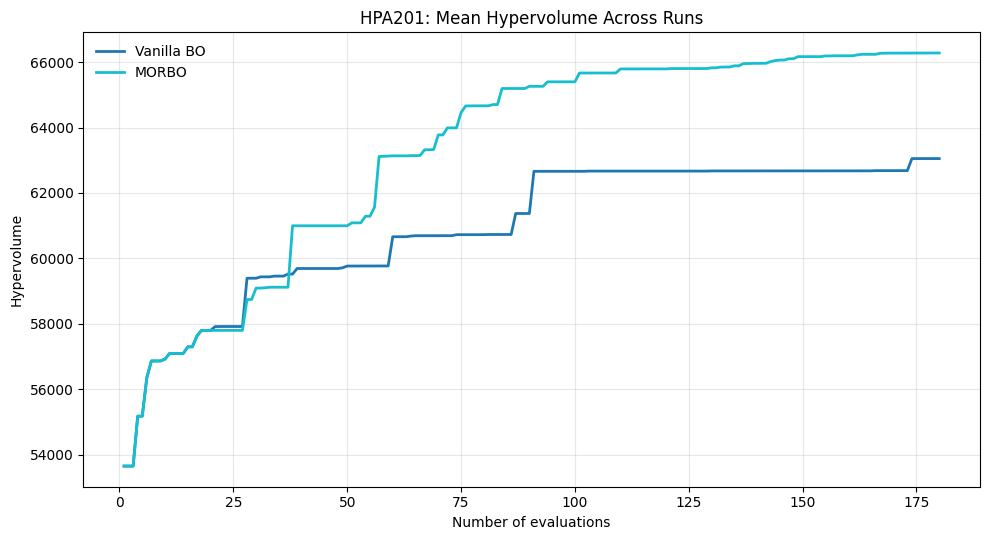

In [ ]:
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(combined_runs)))

fig, ax = plt.subplots(figsize=(10, 5.5))

for color, run in zip(colors, combined_runs):
    hist = run['history_mean']

    mean_vals = hist['mean_hypervolume']
    std_vals = hist['std_hypervolume']

    ax.plot(
        hist['evaluation'],
        mean_vals,
        color=color,
        lw=2.0,
        label=run['label'],
    )

    ax.fill_between(
        hist['evaluation'],
        mean_vals - std_vals,
        mean_vals + std_vals,
        color=color,
        alpha=0.15,
    )

ax.set_title(f'{problem_name}: Mean Hypervolume Comparison Across Runs')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Hypervolume')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=False)

plt.tight_layout()
plt.show()
